# EDA on Titanic
## 1. Load & Understand Data
- Load CSV, basic inspection

In [72]:
#Import libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [73]:
#Import dataset from seaborn 
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [74]:
print(f"rows {df.shape[0]} columns {df.shape[1]} in the dataset")

rows 891 columns 15 in the dataset


In [75]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [76]:
df.dtypes # Checking dtypes so that it is easy to change dataype of a certain column while cleaning or visualizing data

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [77]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [78]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [79]:
df.drop('class', axis=1, inplace=True) #We've encountered redundent columns pclass and class so dropping one column makes sense

## Variables Description:
- survived: Survival status of the passenger — 1 = survived, 0 = did not survive
- pclass: Ticket class — 1 = 1st (upper class), 2 = 2nd (middle class), 3 = 3rd (working class)
- sex: Gender of the passenger — male or female
- age: Age of the passenger in years
- sibsp: Number of siblings and/or spouses aboard with the passenger
- parch: Number of parents and/or children aboard with the passenger
- fare: Ticket fare paid by the passenger
- who: Passenger type — man, woman, or child (based on gender and age)
- adult_male: Boolean — True if passenger is an adult male, else False
- deck: Cabin deck — represented by letters like A, B, C, etc.
- embark_town: Port of embarkation — Cherbourg, Queenstown, or Southampton
- alive: Survival status in text form — yes or no
- alone: Boolean — True if passenger had no family aboard, else False

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  deck         203 non-null    category
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.7+ KB


In [81]:
## Getting and visualizaing missing values 

In [82]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

Text(0.5, 1.0, 'Heatmap of missing values')

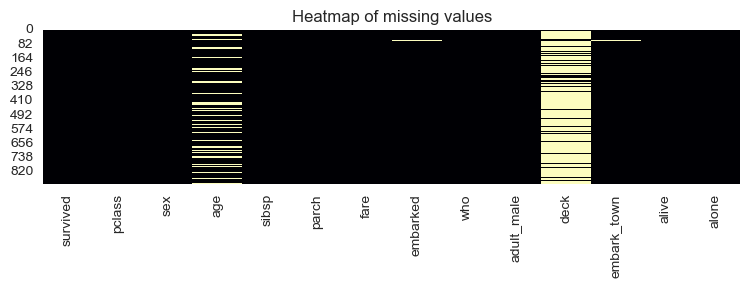

In [83]:
plt.figure(figsize=(9,2))
sns.heatmap(df.isnull(),cmap='magma',cbar=False)
plt.title("Heatmap of missing values")

In [84]:
(df.isnull().mean() * 100).sort_values(ascending=False)
#With tihs we can understand that why the embark_town doesn't not show on heatmap because it has very less number missing values

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64

In [85]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'who', 'adult_male', 'deck', 'embark_town', 'alive',
       'alone'],
      dtype='object')

# Handling missing values 
- Finding missing values 
- Handling missing values 

In [86]:
#Show columns where values are missing  
df.columns[df.isnull().any()] #Here we use any to find if atleast any one values is null (True) in the columns 

Index(['age', 'embarked', 'deck', 'embark_town'], dtype='object')

In [87]:
#Sum of total number of missing values in a columns 
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### obervations:
- 2 NaN in embark_town
- 177 NaN in age
- 688 NaN in deck

### filling missing values

In [96]:
df['age'] = df['age'].fillna(df['age'].mean())
df['embark_town'] = df['embark_town'].fillna('Unknown')
common_deck = df['deck'].mode()[0]
df['deck'] = df['deck'].fillna(common_deck)
df = df.dropna(subset=["embarked"])

In [97]:
df.isnull().sum() #Checking if there are still any missing values

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

# Visualizations 

### Heatmap to visualize relationship between sibsp--parch--age--survived--fare

<Axes: >

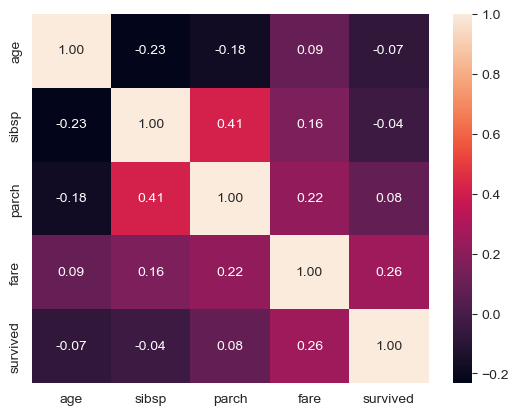

In [90]:
list = ['age','sibsp','parch','fare','survived']
sns.heatmap(data=df[list].corr(),annot=True,fmt='.2f')

Fare shows a moderate positive correlation with survival **(0.26)**, indicating that passengers who paid higher fares were more likely to survive.

### sibsp---survived

Text(9.444444444444445, 0.5, 'Survival Probability')

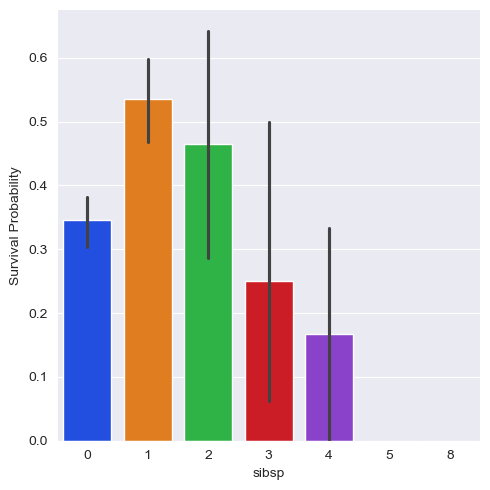

In [91]:
sns.set_style('darkgrid')
sns.catplot(data=df,x='sibsp',y='survived',kind='bar',palette='bright',legend=False,hue='sibsp')
plt.ylabel('Survival Probability',fontweight=12)

- having a lot of sibsp makes chances of survival less (sibsp == 3,4)
- having sibsp == 0,1,2 makes survival chances more 

### Parch--survived

Text(9.444444444444445, 0.5, 'Survival Probability')

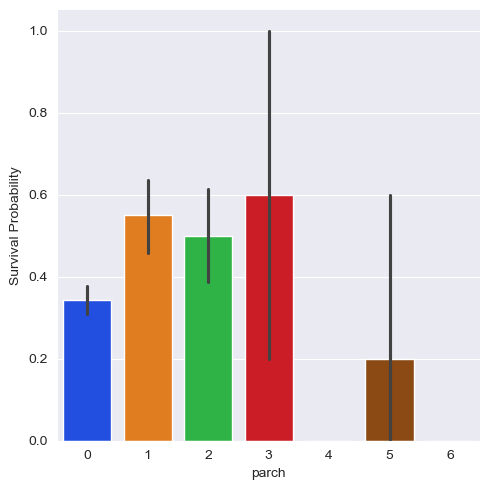

In [92]:
sns.set_style('darkgrid')
sns.catplot(data=df,x='parch',y='survived',kind='bar',palette='bright',legend=False,hue='parch')
plt.ylabel('Survival Probability',fontweight=12)

Family of less members are tend to survive more

### pclass---survived

Text(9.444444444444445, 0.5, 'Survival Probability')

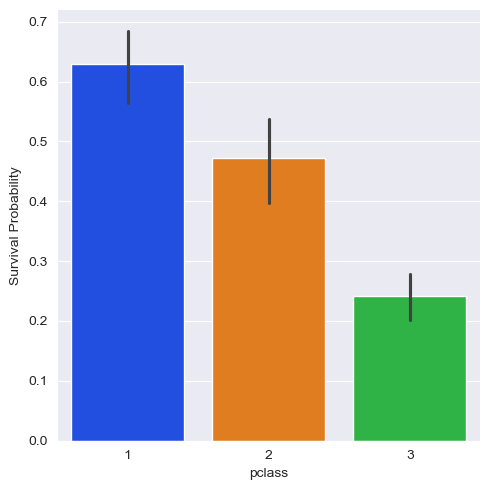

In [93]:
sns.set_style('darkgrid')
sns.catplot(data=df,x='pclass',y='survived',kind='bar',palette='bright',legend=False,hue='pclass')
plt.ylabel('Survival Probability',fontweight=12)

People in 1st class survived more followed by 2 and 3(with less survival)

### Age--Survived

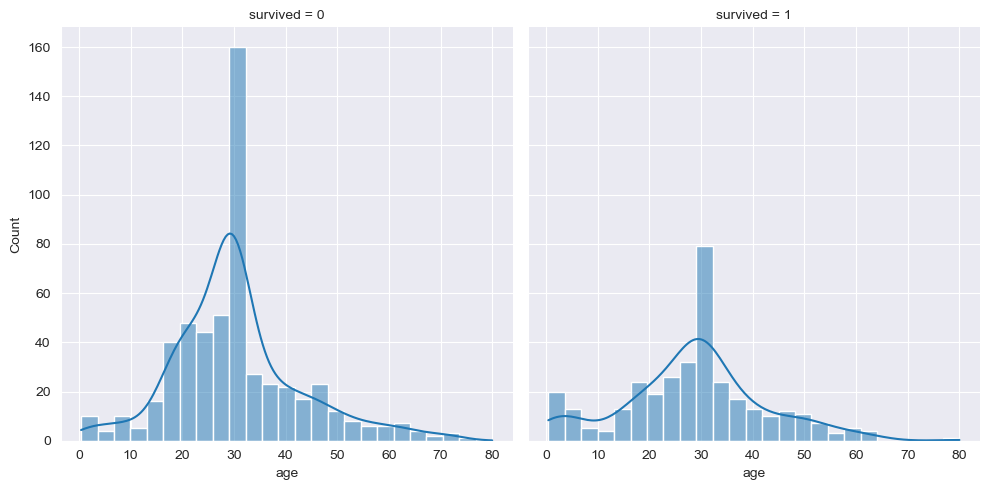

In [94]:
sns.displot(data=df, x="age", col="survived", bins=25, kde=True)

- age<= 10 survived more
- age = 20 has large number of deaths
- most passangers falls under the age 15-45
- oldest passanger is 80 Years old

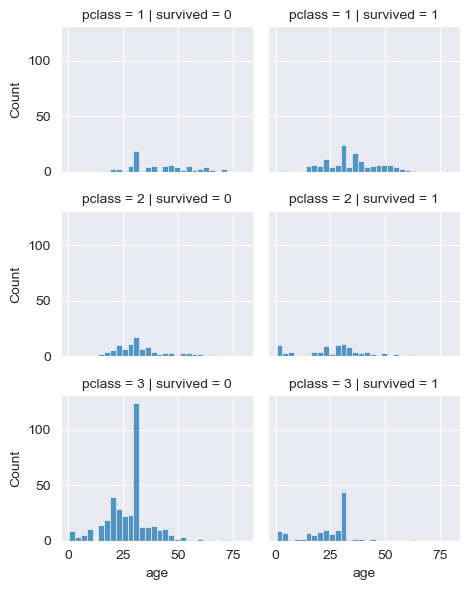

In [105]:
### Pclass--age--survived
sns.displot(data=df,x='age',col='survived',row='pclass',bins=30,height=2,aspect=1.2)

### embarked--fare--survived--sex

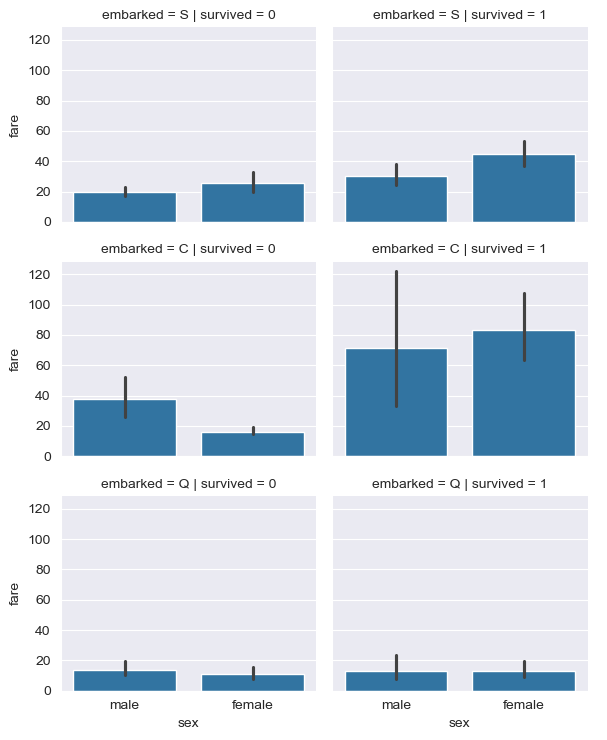

In [98]:
sns.catplot(
    data=df,
    x="sex",
    y="fare",
    col="survived",
    row="embarked",
    kind="bar",
    height=2.5,
    aspect=1.2
)
plt.show()


higher fare == better survival rate

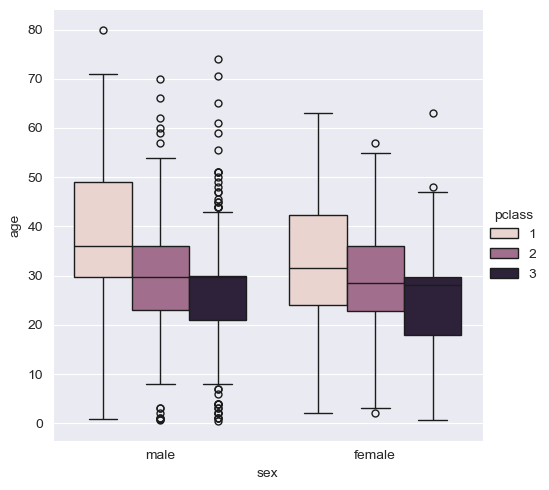

In [106]:
sns.catplot(
    df,
    x='sex',
    y='age',
    kind='box',
    hue='pclass'
)

1st class passenger are older than 2nd and 2nd older than third